# **White Blood Cell Classification**

## Objective
In this notebook, you will train a convolutional neural network (ConvNet) to classify white blood cells into two categories:
1. Lymphoblasts (indicative of leukemia)
2. Normal white blood cells

We will use a custom dataset for this classification task. Details on the initial dataset can be found here: https://scotti.di.unimi.it/all/

The exercise will guide you step-by-step from data loading and preparation to building and training a deep learning model.

Types of leukemia: https://www.leukaemiacare.org.uk/types-of-leukaemia/

Morphology of leukemia: https://www.sciencedirect.com/science/article/pii/S0185106315000724

Examples of different WBC (Fig. 2): https://www.nature.com/articles/s41597-023-02378-7

Review on blood film analysis analysis with AI: https://www.sciencedirect.com/science/article/pii/S0268960X23001054



## Primer on Convolutional Neural Networks (CNN)

<p align="center">
  <img src="https://cdn.analyticsvidhya.com/wp-content/uploads/2020/10/90650dnn2.webp" width="600">
</p>

### What are CNNs?

CNNs are deep learning architectures designed to **analyse images**.  

They automatically learn **patterns, textures, and shapes**, making them ideal for tasks like classifying white blood cells.  

---

### How do they work?

- Like a classic neural network, CNNs have **weights and biases** learned during training.  
- These weights are arranged in **convolutional kernels (filters)** that slide across the image to detect features such as edges, textures, or shapes.  

<p align="center">
  <img src="https://goodboychan.github.io/images/copied_from_nb/image/convolutions.gif" width="250">
</p>

- **Stride and padding**: control how filters move across the image and maintain spatial dimensions.
  - **Stride** defines by how much the filter moves each time it slides across the image. A larger stride skips pixels, producing smaller feature maps (more downsampling).  
  - **Padding** adds extra pixels (usually zeros) around the image edges, ensuring that features near the borders are also captured and that the output keeps its original size.

  Example using **padding = 1 and stride = 1**. Note that the output has changed dimensions compared to the case above (no padding and stride = 2).
<p align="center">
  <img src="https://webflow-prod-assets.s3.amazonaws.com/6525256482c9e9a06c7a9d3c%2F65b021e050b6cc5df6a37f14_2Convolution_arithmetic_-_Same_padding_no_strides_transposed.gif" width="300">
</p>


- **Convolution operation**: the filter actually computes a dot product with local pixels to detect features.  

<p align="center">
  <img src="https://miro.medium.com/v2/resize:fit:640/format:webp/1*NTT0zXwzocde7nHUSaYENg.png" width="450">
</p>

- **Feature maps**: the output of a convolution is called a feature map.  

- CNNs also use **activation functions** (e.g., ReLU) to capture complex patterns.  

<p align="center">
  <img src="https://images.prismic.io/encord/96630d33-5206-4c76-84f9-8b57aabee7c1_CNN+2.png?auto=compress,format" width="500">
</p>

- **Pooling layers** shrink feature maps while keeping the most important information, helping the network focus on different levels of abstraction (e.g., max or average pooling).  
<p align="center">
  <img src="https://cdn.analyticsvidhya.com/wp-content/uploads/2024/08/597371-kqieqhxzicu7thjaqbfpbq-66c7045e59b1e.webp" width="300">
</p>

- **Dense (fully connected) layers**: These layers are placed at the end of the network and are responsible for **classification**.  
  After the convolution and pooling layers have extracted and summarised features, the dense layers take this information and learn **how those features combine to represent specific classes** (e.g., normal vs. lymphoblast). The output layer then produces the **final prediction**. For example, a single value between 0 and 1 (using a sigmoid activation) in binary classification.



## 📚 0. Import Libraries (Nothing to do)

In [2]:
# from google.colab import drive
# drive.mount('/content/drive/')

In [3]:
# Importing necessary libraries
import tensorflow as tf  # TensorFlow for deep learning
import os  # For handling file paths
import numpy as np  # For data manipulation
import matplotlib.pyplot as plt  # For visualizing the dataset

from tensorflow.keras.preprocessing.image import ImageDataGenerator  # For loading and augmenting image data
from sklearn.model_selection import train_test_split  # For splitting custom dataset into train and test
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # For evaluating model performance

## 👓 1. Download the dataset from moodle
You will use a custom dataset of images that contain lymphoblasts and normal white blood cells. Make sure the dataset is organized in two folders: "lymphoblast" and "healthy", with images placed in their respective folders. Upload it on your google drive if you are using colab.


In [4]:
# Define dataset paths
base_dir = r"C:\Users\adria\Documents\ai_4_bh\lab_02\all_data"  # Update this to the actual path
#normal_dir = os.path.join(base_dir, 'normal')
#lymphoblast_dir = os.path.join(base_dir, 'lymphoblasts')

# Define parameters
IMG_HEIGHT, IMG_WIDTH = 128, 128
BATCH_SIZE = 32
NUM_EPOCHS=10
RAN_SEED=17

# Use ImageDataGenerator for loading and splitting data
datagen = ImageDataGenerator(
    rescale=1.0/255,  # Normalize pixel values
    validation_split=0.5)  # Split 20% of the data for validation

# Creating train and validation datasets
train_data = datagen.flow_from_directory(
    base_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=RAN_SEED
)

validation_data = datagen.flow_from_directory(
    base_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=RAN_SEED
)

print("Training and validation datasets prepared successfully.")


Found 130 images belonging to 2 classes.
Found 130 images belonging to 2 classes.
Training and validation datasets prepared successfully.


###  1.2 : Visualize the Dataset

❗ Display some images from the training dataset to understand the data better. Use the function bellow or build your own.


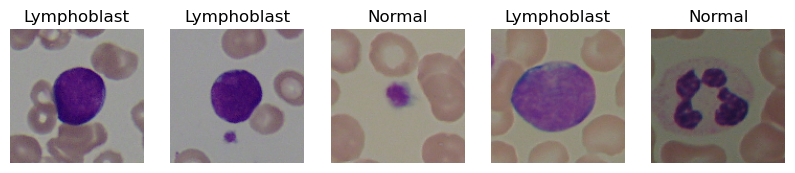

In [5]:
# Function to display a few images from the dataset
def visualize_dataset(dataset, num_images=5):
    plt.figure(figsize=(10, 10))
    for i, (image, label) in enumerate(dataset):
        if i >= num_images:
            break
        plt.subplot(1, num_images, i + 1)
        plt.imshow(image[0])  # Image comes as a batch, so we take the first image
        plt.title("Lymphoblast" if label[0] == 1 else "Normal")
        plt.axis("off")
    plt.show()

visualize_dataset(train_data)


## 🧱 3. Build a simple ConvNet

Here you will build a simple convolutional neural network (CNN) to classify lymphoblasts and normal white blood cells.

❗ **Add in the missing layers**. To prevent overfitting, add also 0.2 dropout rate during training where specified. Hint: check out https://keras.io/api/layers/

In [10]:
# Build a simple CNN model
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    #Add a pooling layer here. You need to add "," after each layer
    ## add your code here ###,
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    #Add a pooling layer here. You need to add "," after each layer
    ## add your code here #### ,
    tf.keras.layers.MaxPooling2D(2, 2),

    #Add a Convolutional layer here with 64 filters. You need to add "," after each layer
    ## add your code here.... ##,
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),

    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Binary classification output
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

c:\Users\adria\anaconda3\envs\py311_ai4bh\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


❗**How many parameters does your model have?** Hint: use the keras.model API to summarize your model: https://keras.io/api/models/

In [11]:
# Print the model summary
## .. add line of code here .. ##
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,629,473 (6.22 MB)

 Trainable params: 1,629,473 (6.22 MB)

 Non-trainable params: 0 (0.00 B)

### 3.1 Train the Model

We will now train the model using the training and validation datasets.


In [12]:
# Train the model
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=NUM_EPOCHS,  # You can increase the number of epochs based on your needs
    verbose=1
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step - accuracy: 0.4923 - loss: 0.7713 - val_accuracy: 0.5154 - val_loss: 0.7386
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.4692 - loss: 0.7005 - val_accuracy: 0.4846 - val_loss: 0.6961
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5538 - loss: 0.6885 - val_accuracy: 0.5154 - val_loss: 0.6887
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5154 - loss: 0.6850 - val_accuracy: 0.5154 - val_loss: 0.6878
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5154 - loss: 0.6996 - val_accuracy: 0.6000 - val_loss: 0.6695
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.7692 - loss: 0.6559 - val_accuracy: 0.6692 - val_loss: 0.6619
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.8000 - loss: 0.6252 - val_accuracy: 0.6846 - val_loss: 0.6312
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.7077 - loss: 0.5737 - val_accuracy: 0.6846 - val_loss: 0.5781

### 3.1: Evaluate and Visualize Results

❗Evaluate your model on the validation data. Hint: call the apropriate method using the keras API : https://keras.io/api/models/

What is the accuracy on the validation set?

❗(Optional) Compute the confusion matrix!

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6615 - loss: 0.5748
Validation Accuracy: 0.66
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


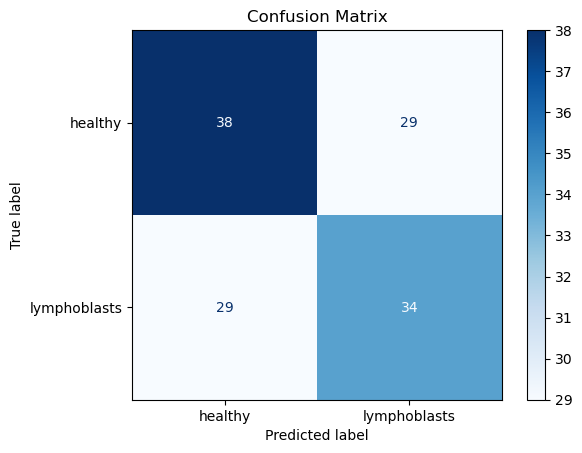

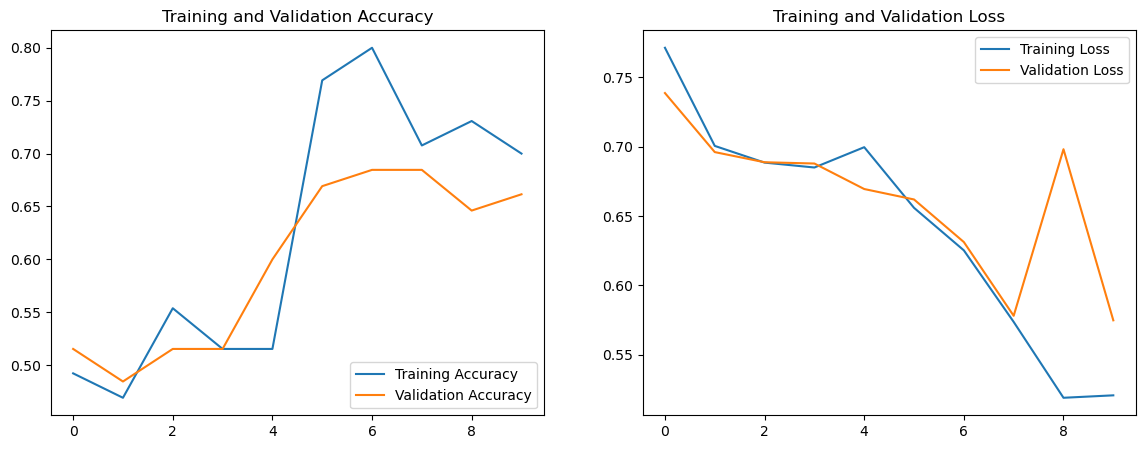

In [13]:
# Evaluate the model
loss, accuracy = model.evaluate(validation_data) ### write your line of code here ###
print(f"Validation Accuracy: {accuracy:.2f}")


# Get predictions (probabilities)
y_pred_probs = model.predict(validation_data)
# Convert probabilities to class indices (0 or 1 for binary classification)
y_pred = np.argmax(y_pred_probs, axis=1) if y_pred_probs.shape[1] > 1 else np.round(y_pred_probs).astype(int).flatten()
# Get true labels
y_true = validation_data.classes

# Compute confusion matrix & plot it
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=validation_data.class_indices
.keys())
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Plot training and validation accuracy over epochs
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

## ➡️ 4. Transfer Learning

Training a CNN from scratch, like the one above, is a great way to understand how these models work.  
However, in real-world biomedical imaging tasks, we often face two major challenges:

1. **Limited data:** Medical datasets are usually small, and training deep networks from scratch can easily lead to **overfitting**.  
2. **Training cost:** Training a large CNN from random weights can require substantial **computational resources** and time.

To address these challenges, we use **transfer learning**. Instead of starting from scratch, we start from a model that has already **learned useful visual features** from millions of images (e.g., edges, textures, shapes) — such as **MobileNet**, which was trained on the large **ImageNet** dataset.

We then **reuse** the convolutional base of this pretrained model and **adapt** it to our own task (white blood cell classification).

---


In this section, you will use a pretrained MobileNet model, leveraging its features for classifying lymphoblasts vs normal white blood cells.

❗Modify the code below so that your model uses MobileNet's convolutional layers (without the top fully connected layers) pretrained on the ImageNet dataset. Hint: checkout the keras aplications examples: https://keras.io/api/applications/

❗Add a global pooling layer after the base model (Hint: it's already imported).

❗ Compare the following the following:

a) train only the FC layers (freezing the convnet layers)

b) train from scratch (no pre-trained weights) - (only if you have time left)

c) fine-tune all layers - (only if you have time left)

❗For a) you need to freeze the MobileNet base model layers so that only the newly added fully connected dense layers are optimized. (Hint: check out the keras layer documentation: https://keras.io/api/layers/base_layer/#layer-class. You need to change the value of one of the layer attributes) Or have a look at : https://keras.io/guides/transfer_learning/

In [14]:
import tensorflow
from tensorflow.keras.applications.mobilenet import MobileNet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.layers import Input
# Load MobileNetV2 pretrained on ImageNet and add custom layers for our binary classification task
input_tensor = Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
# create the base pre-trained model on ImageNet with a custom input tensor

base_model = MobileNet(
     ### ... add lines here ...###
     input_tensor=input_tensor,
     weights='imagenet',
     include_top=False,
)

# Freeze the base model to use it as a feature extractor
## ... add code here ... ##
base_model.trainable = False

# Add custom layers on top of the base model
model_mobilenet = tf.keras.Sequential([
    base_model,
    ## ... add code here ##
    # Add a global spatial average pooling layer
    tf.keras.layers.GlobalAveragePooling2D(),
    # let's add a fully-connected layer
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),  # Add dropout to prevent overfitting
    # and a classification layer
    tf.keras.layers.Dense(1, activation='sigmoid')  # Binary classification output
])

#model_mobilenet2 = tensorflow.keras.models.clone_model(model_mobilenet)

# Compile the model
model_mobilenet.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Print the model summary
model_mobilenet.summary()

C:\Users\adria\AppData\Local\Temp\ipykernel_25892\2240756939.py:10: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNet(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_1.00_224 (Functional) │ (None, 4, 4, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,360,193 (12.82 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

### 4.1 Train the MobileNet Model (Nothing to do)

You will now train the model using the training and validation datasets.

In [15]:
# Train the model
history_mobilenet = model_mobilenet.fit(
    train_data,
    validation_data=validation_data,
    epochs=NUM_EPOCHS,  # You can increase the number of epochs based on your needs
    verbose=1
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 343ms/step - accuracy: 0.5769 - loss: 0.8228 - val_accuracy: 0.5846 - val_loss: 0.8679
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.7154 - loss: 0.6232 - val_accuracy: 0.6000 - val_loss: 0.8530
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.8000 - loss: 0.4618 - val_accuracy: 0.6308 - val_loss: 1.0635
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.8923 - loss: 0.3150 - val_accuracy: 0.6923 - val_loss: 0.7618
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.9154 - loss: 0.2176 - val_accuracy: 0.6538 - val_loss: 0.8073
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.9154 - loss: 0.2170 - val_accuracy: 0.6769 - val_loss: 0.7131
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.9538 - loss: 0.1423 - val_accuracy: 0.7000 - val_loss: 0.7670
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.9692 - loss: 0.1331 - val_accuracy: 0.6846 - val_loss:

### 4.2 Visualize the results


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6923 - loss: 0.6719
Validation Accuracy: 0.69


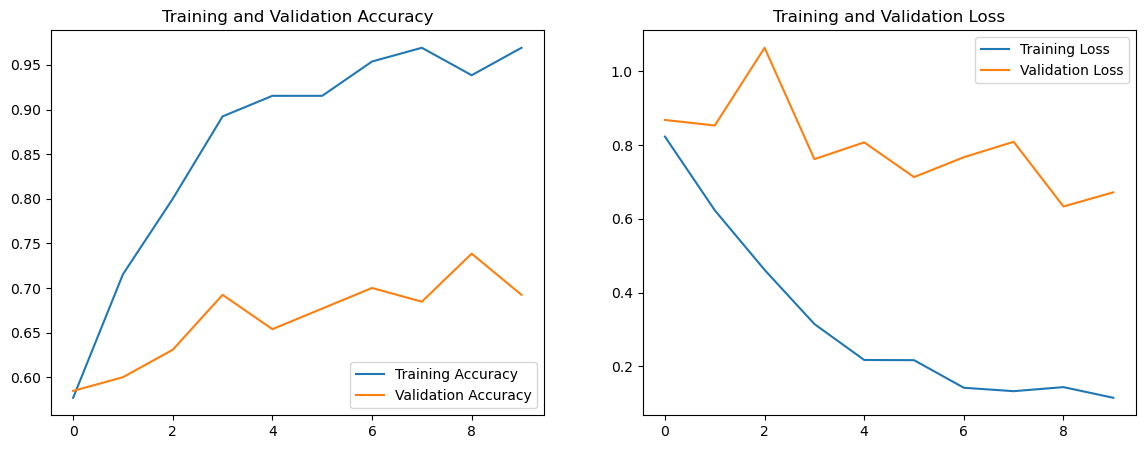

In [16]:
# Evaluate the model
loss, accuracy = model_mobilenet.evaluate(validation_data)
print(f"Validation Accuracy: {accuracy:.2f}")

# Plot training and validation accuracy over epochs
acc = history_mobilenet.history['accuracy']
val_acc = history_mobilenet.history['val_accuracy']
loss = history_mobilenet.history['loss']
val_loss = history_mobilenet.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

## 🔧 5. Data Augmentation

To make our model more robust and reduce overfitting, here you will apply data augmentation techniques.


❗ **Add augmentation layers to your model before the first convolutional layer below.** An example of such a layer is provided. Add one geometrical augmentation and one spectral (related to the image color/luminance). *Hint*: use the image augmentation layers provided by the keras api:
https://keras.io/api/layers/preprocessing_layers/image_augmentation/

In [17]:
# Adding data augmentation to the training dataset

# Add augmentation layers before the base model
model_mobilenet2 = tf.keras.Sequential([
    #Add augmentation layers here [In sequential mode, you need to add "," after each layer]
   ##...add line of code here ..##
    tf.keras.layers.AugMix(),
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),  # Add dropout to prevent overfitting
    tf.keras.layers.Dense(1, activation='sigmoid')  # Binary classification output
])
# Compile the model
model_mobilenet2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
# Re-train the original model with augmented data
history_augmented = model_mobilenet2.fit(
    train_data,
    validation_data=validation_data,
    epochs=NUM_EPOCHS,  # You can adjust the number of epochs
    verbose=1
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 749ms/step - accuracy: 0.4462 - loss: 1.0912 - val_accuracy: 0.4846 - val_loss: 1.5142
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - accuracy: 0.6385 - loss: 0.6665 - val_accuracy: 0.4538 - val_loss: 0.9059
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.6923 - loss: 0.6858 - val_accuracy: 0.4846 - val_loss: 1.5631
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.6769 - loss: 0.7258 - val_accuracy: 0.4923 - val_loss: 1.3814
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - accuracy: 0.6538 - loss: 0.5956 - val_accuracy: 0.5231 - val_loss: 0.9102
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.7077 - loss: 0.6106 - val_accuracy: 0.5231 - val_loss: 1.2627
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.7846 - loss: 0.5025 - val_accuracy: 0.5923 - val_loss: 0.7980
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - accuracy: 0.7846 - loss: 0.4662 - val_accuracy: 0.6000 - val_loss:

### 5.1 Visualize the results

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5385 - loss: 0.7447
Validation Accuracy: 0.54


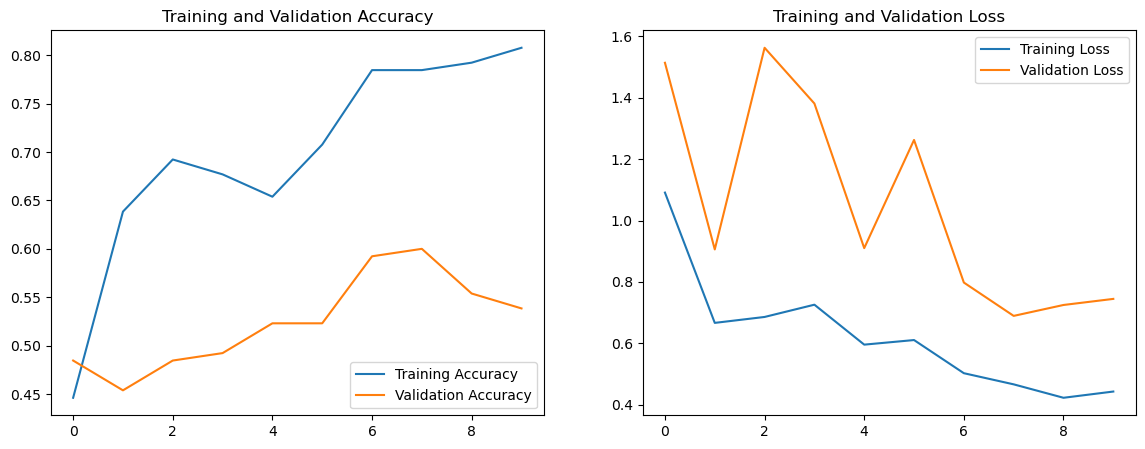

In [18]:
# Evaluate the model
loss, accuracy = model_mobilenet2.evaluate(validation_data)
print(f"Validation Accuracy: {accuracy:.2f}")

# Plot training and validation accuracy over epochs
acc = history_augmented.history['accuracy']
val_acc = history_augmented.history['val_accuracy']
loss = history_augmented.history['loss']
val_loss = history_augmented.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

### 5.2 Compare the performance of your models

❗**Plot the ROC curves and compute the AUC for each of your trained models**. Use the function bellow or build your own.  
❗**(Optional) Compute the confusion matrices**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 667ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 563ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 622ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 579ms/step


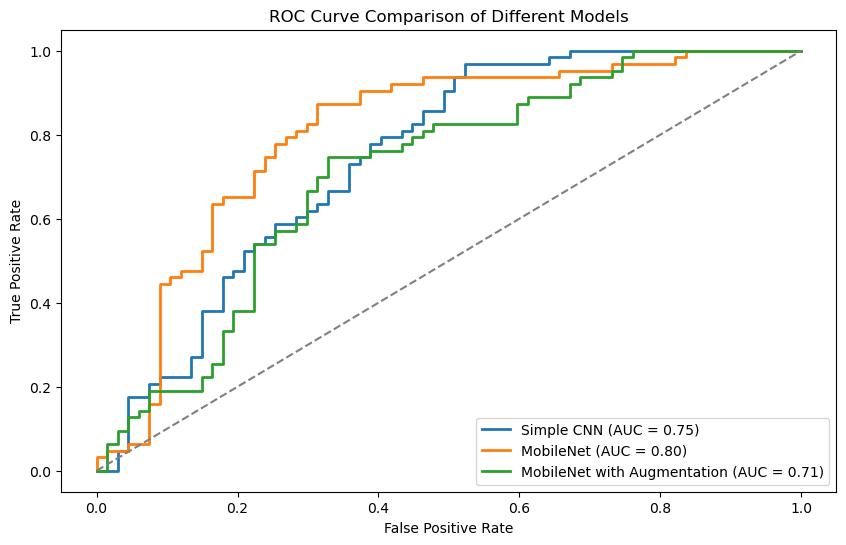

In [19]:
from sklearn.metrics import roc_curve, auc
import numpy as np

# Function to plot ROC curves for multiple models on the same plot
def plot_roc_curves(models, validation_data_list, labels, title="ROC Curve Comparison"):
    plt.figure(figsize=(10, 6))

    # Iterate over each model and its corresponding validation data
    for model, validation_data, label in zip(models, validation_data_list, labels):
        y_true = []
        y_pred = []

        # Get true labels and predicted probabilities
        for images, labels_batch in validation_data:
            y_true.extend(labels_batch)
            preds = model.predict(images)
            y_pred.extend(preds)

            # Break after one full pass (since it's a generator)
            if len(y_true) >= validation_data.samples:
                break

        y_true = np.array(y_true)
        y_pred = np.array(y_pred)

        # Compute False Positive Rate (FPR) and True Positive Rate (TPR)
        fpr, tpr, _ = roc_curve(y_true, y_pred)
        roc_auc = auc(fpr, tpr)

        # Plot the ROC Curve for the current model
        plt.plot(fpr, tpr, lw=2, label=f'{label} (AUC = {roc_auc:.2f})')

    # Plot the random guess line
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random guess line

    # Configure plot settings
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()

# Plot ROC curves for the original model and MobileNet models on the same plot

###... Add your code here ... ###
plot_roc_curves(
    models=[model, model_mobilenet, model_mobilenet2],
    validation_data_list=[validation_data, validation_data, validation_data],
    labels=['Simple CNN', 'MobileNet', 'MobileNet with Augmentation'],
    title="ROC Curve Comparison of Different Models"
)
